In [26]:
import copy
import numpy as np
import torch
import matplotlib.pyplot as plt
import datasets
import unet
from unet import *
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_sims = np.load("../train_sims.npy")
train_sims = train_sims[train_sims < 750]
val_sims = np.load("../val_sims.npy")
val_sims = val_sims[val_sims < 750]
test_sims = np.load("../test_sims.npy")
test_sims = test_sims[test_sims < 750]


In [38]:
# Helper: build one sample at (sim_id, t)
# ---------------------------
def make_sample_for_sim_time_from_dataset(
    dataset_type,
    dataset_arguments: dict,
    sim_id: int,
    t: int,
):
    future_delta = dataset_arguments["future_delta"]
    SIM_STEPS = 201
    # make sure t is valid for the delta
    max_start = (SIM_STEPS - 1) - future_delta
    t = int(min(max(t, 0), max_start))

    args = copy.deepcopy(dataset_arguments)
    args["sims"] = np.array([sim_id], dtype=np.int64)
    args["steps"] = (t, t + 1) 
    #args["future_delta"] = future_delta

    ds = dataset_type(**args)
    item = ds[0]

    if isinstance(item, (tuple, list)) and len(item) == 2:
        feat, label = item
        mask = None
    elif isinstance(item, (tuple, list)) and len(item) == 3:
        feat, label, mask = item
    else:
        raise ValueError(f"Unexpected item format: type={type(item)}")

    return feat, label, mask, t

In [39]:
# Main: Heatmap over sims at fixed time t and horizon Δ
# ---------------------------
def show_heatmap_mse_from_dataset(
    model,
    dataset_type,
    dataset_arguments: dict,
    val_sims: np.ndarray,
    future_delta: int = 0,
    time_val: int = 50,
    sims=None,                 # list of indices of sims, or list of sim_ids if sims_are_ids=True
    sims_are_ids: bool = False,
    channel: int = 1, 
    device=None,
    use_mask_in_error: bool = False,  # if dataset returns mask, compute error only where mask
):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model.eval()

    # sims to evaluate over
    if sims is None:
        N = min(100, len(val_sims))
        sims = list(range(N))

    if sims_are_ids:
        sim0_id = int(sims[0])
    else:
        sim0_id = int(val_sims[int(sims[0])])

    feat0, label0, mask0, t0 = make_sample_for_sim_time_from_dataset(
        dataset_type=dataset_type,
        dataset_arguments=dataset_arguments,
        sim_id=sim0_id,
        t=time_val,
    )

    # label is expected (C,H,W)
    if label0.ndim != 3:
        raise ValueError(f"Expected shape (C,H,W), got {tuple(label0.shape)}")

    C, H, W = label0.shape
    err_accum = torch.zeros((H, W), dtype=torch.float32, device=device)
    count = 0

    example_out = None
    example_label = None

    for s in sims:
        sim_id = int(s) if sims_are_ids else int(val_sims[int(s)])

        feat, label, mask, t_used = make_sample_for_sim_time_from_dataset(
            dataset_type=dataset_type,
            dataset_arguments=dataset_arguments,
            sim_id=sim_id,
            t=time_val,
        )

        feat = feat.to(device).unsqueeze(0)
        label = label.to(device) 

        with torch.no_grad():
            out = model(feat)[0]

        diff = (out[channel] - label[channel]) ** 2

        if use_mask_in_error and (mask is not None):
            m = mask.to(device)
            if m.ndim == 3:
                m = m[0]
            m = m.float()
            diff = diff * m

        err_accum += diff
        count += 1

        if example_out is None:
            example_out = out.detach().cpu()
            example_label = label.detach().cpu()

    mean_err = (err_accum / max(1, count)).detach().cpu().numpy()

    # Plot
    fig, axs = plt.subplots(1, 3, figsize=(12, 4), dpi=250)
    d_txt = f"Δ={future_delta}, t={time_val}, channel={channel}"

    axs[0].imshow(example_label[channel], cmap="gray")
    axs[0].set_title(f"True @ t+Δ\n{d_txt}", fontsize=9)

    axs[1].imshow(example_out[channel], cmap="gray")
    axs[1].set_title("Predicted @ t+Δ", fontsize=9)

    im = axs[2].imshow(mean_err, cmap="magma")
    axs[2].set_title(f"Mean squared error map\n(avg over {count} sims)", fontsize=9)
    fig.colorbar(im, ax=axs[2], fraction=0.046, pad=0.04)

    for ax in axs:
        ax.axis("off")

    fig.tight_layout()
    plt.show()

In [ ]:
dataset_arguments = {
    "points_per_side": 3,
    "radius": 5,
    "types": [0],
    "H": 200,
    "W": 200,
    "channels": "all",
    "future_delta": 0,
}

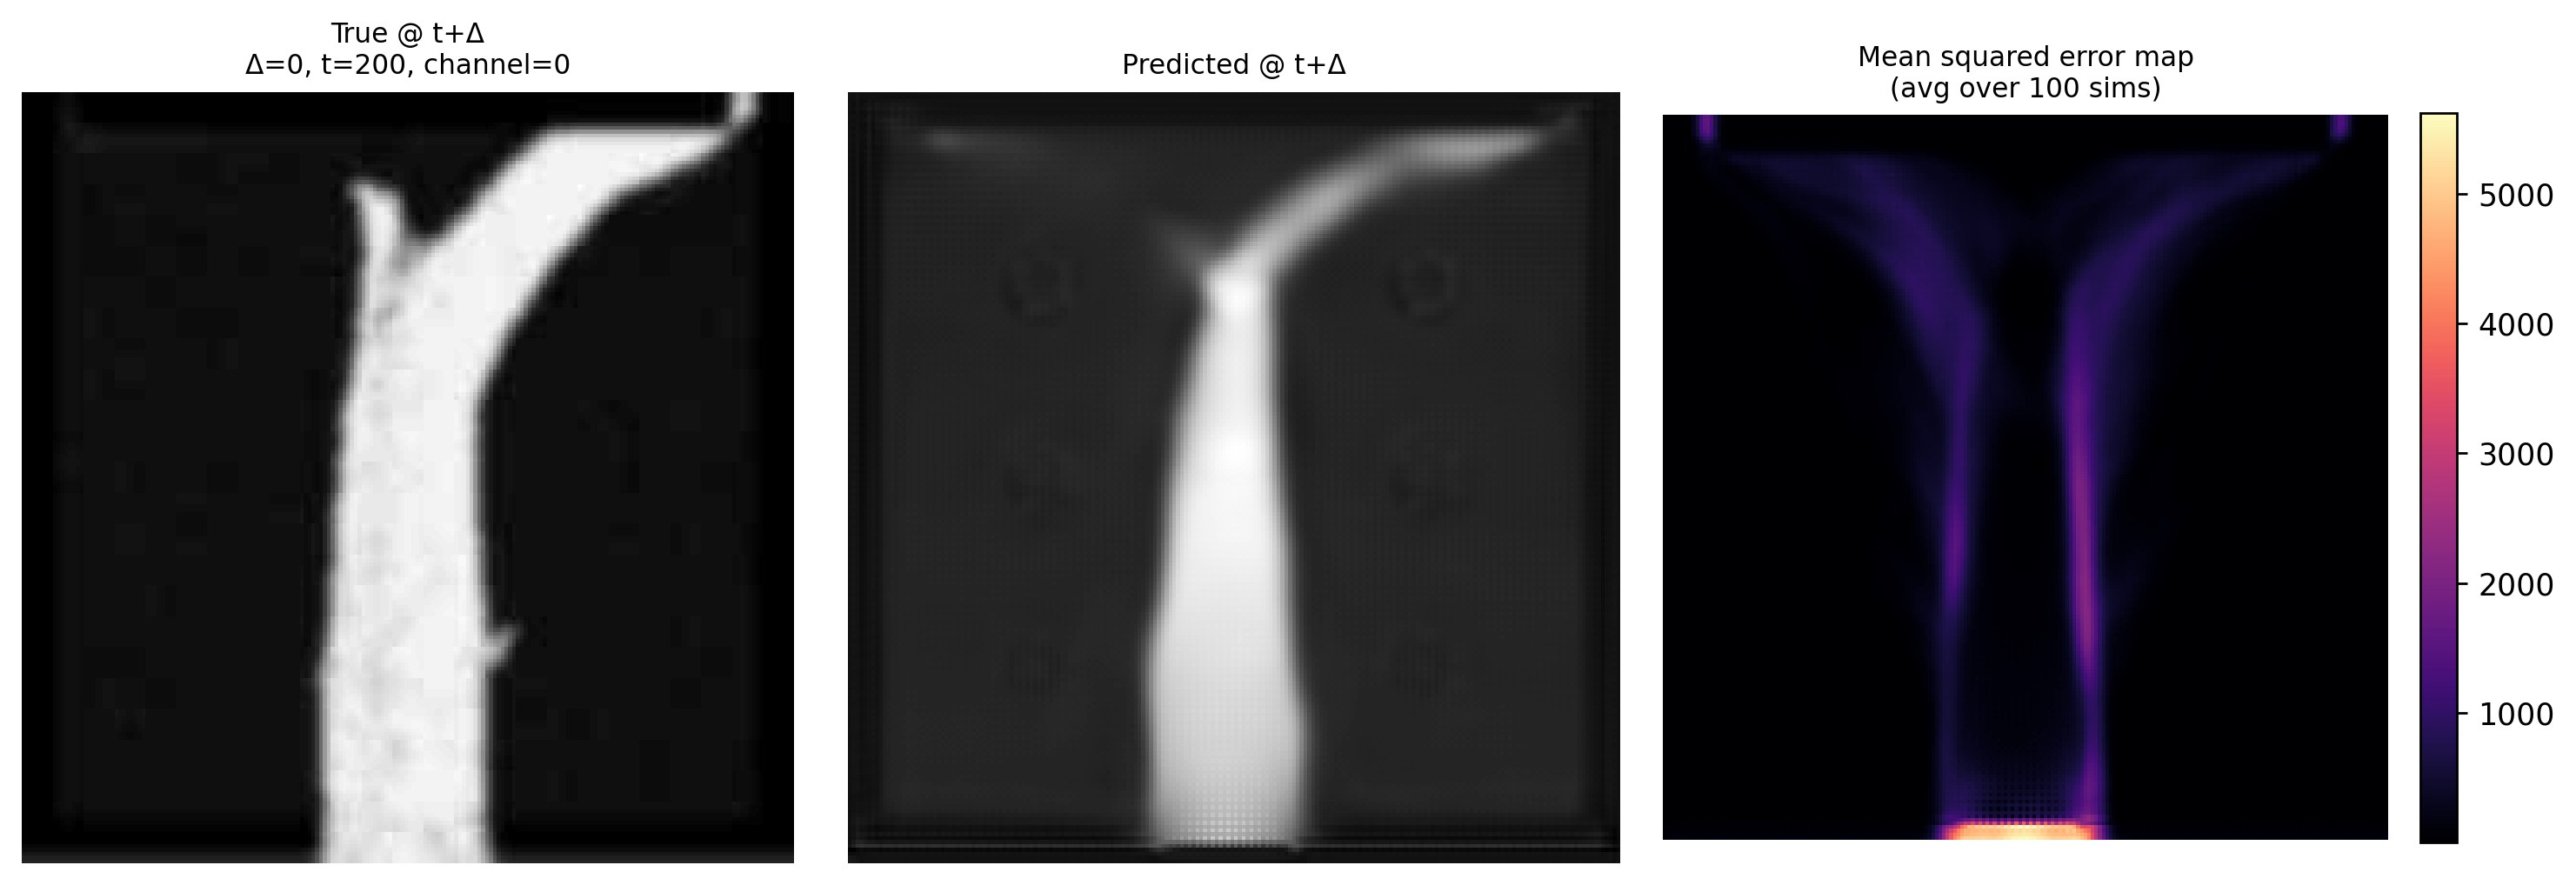

In [ ]:


model = torch.load("full_d0_n16_With_D.pt", weights_only=False, map_location=device).to(device)

# heatmap at t=200
show_heatmap_mse_from_dataset(
    model=model,
    dataset_type=datasets.FixedDenseDatasetFull,
    dataset_arguments=dataset_arguments,
    val_sims=val_sims,
    time_val=200,
    sims=None,          # uses first 100 sims
    channel=0, 
    device=device,
)

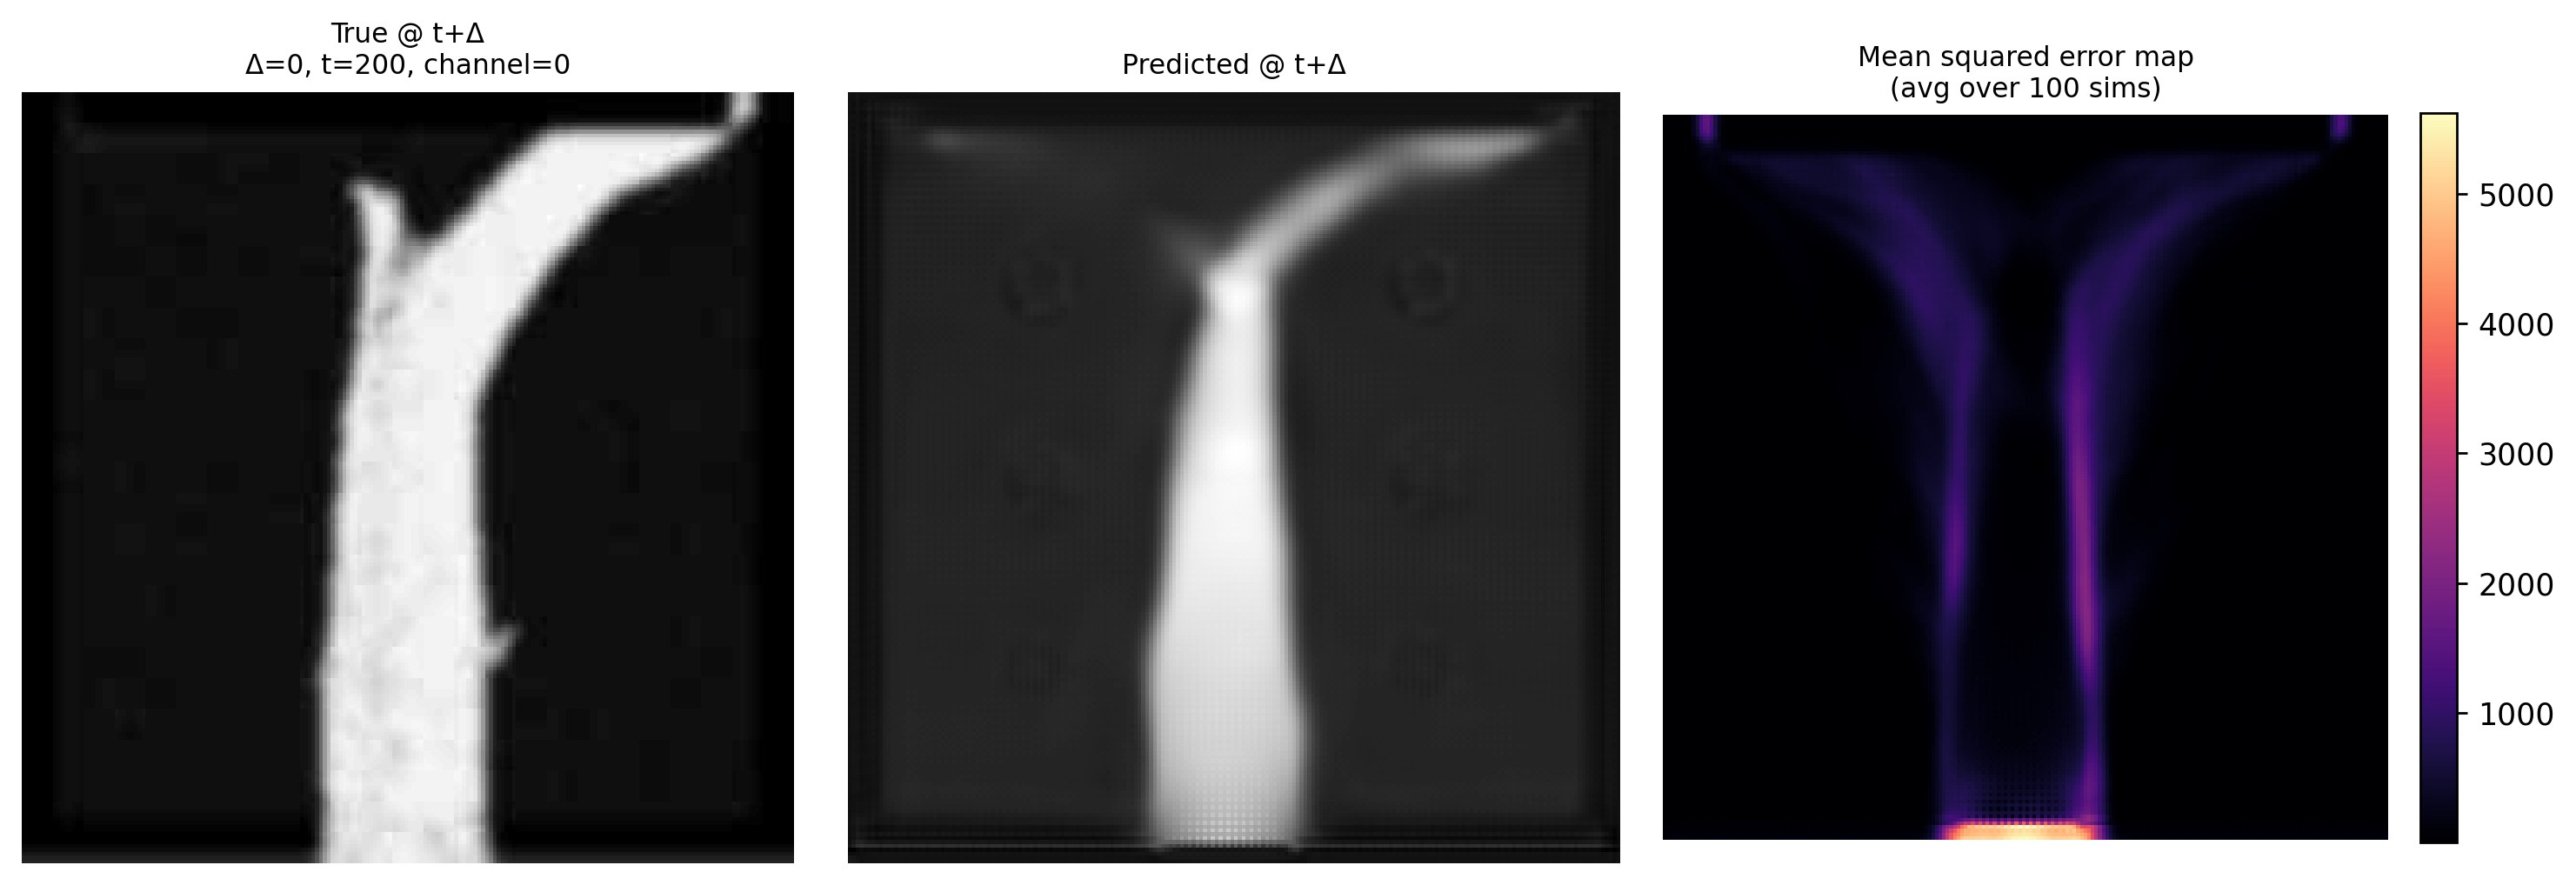

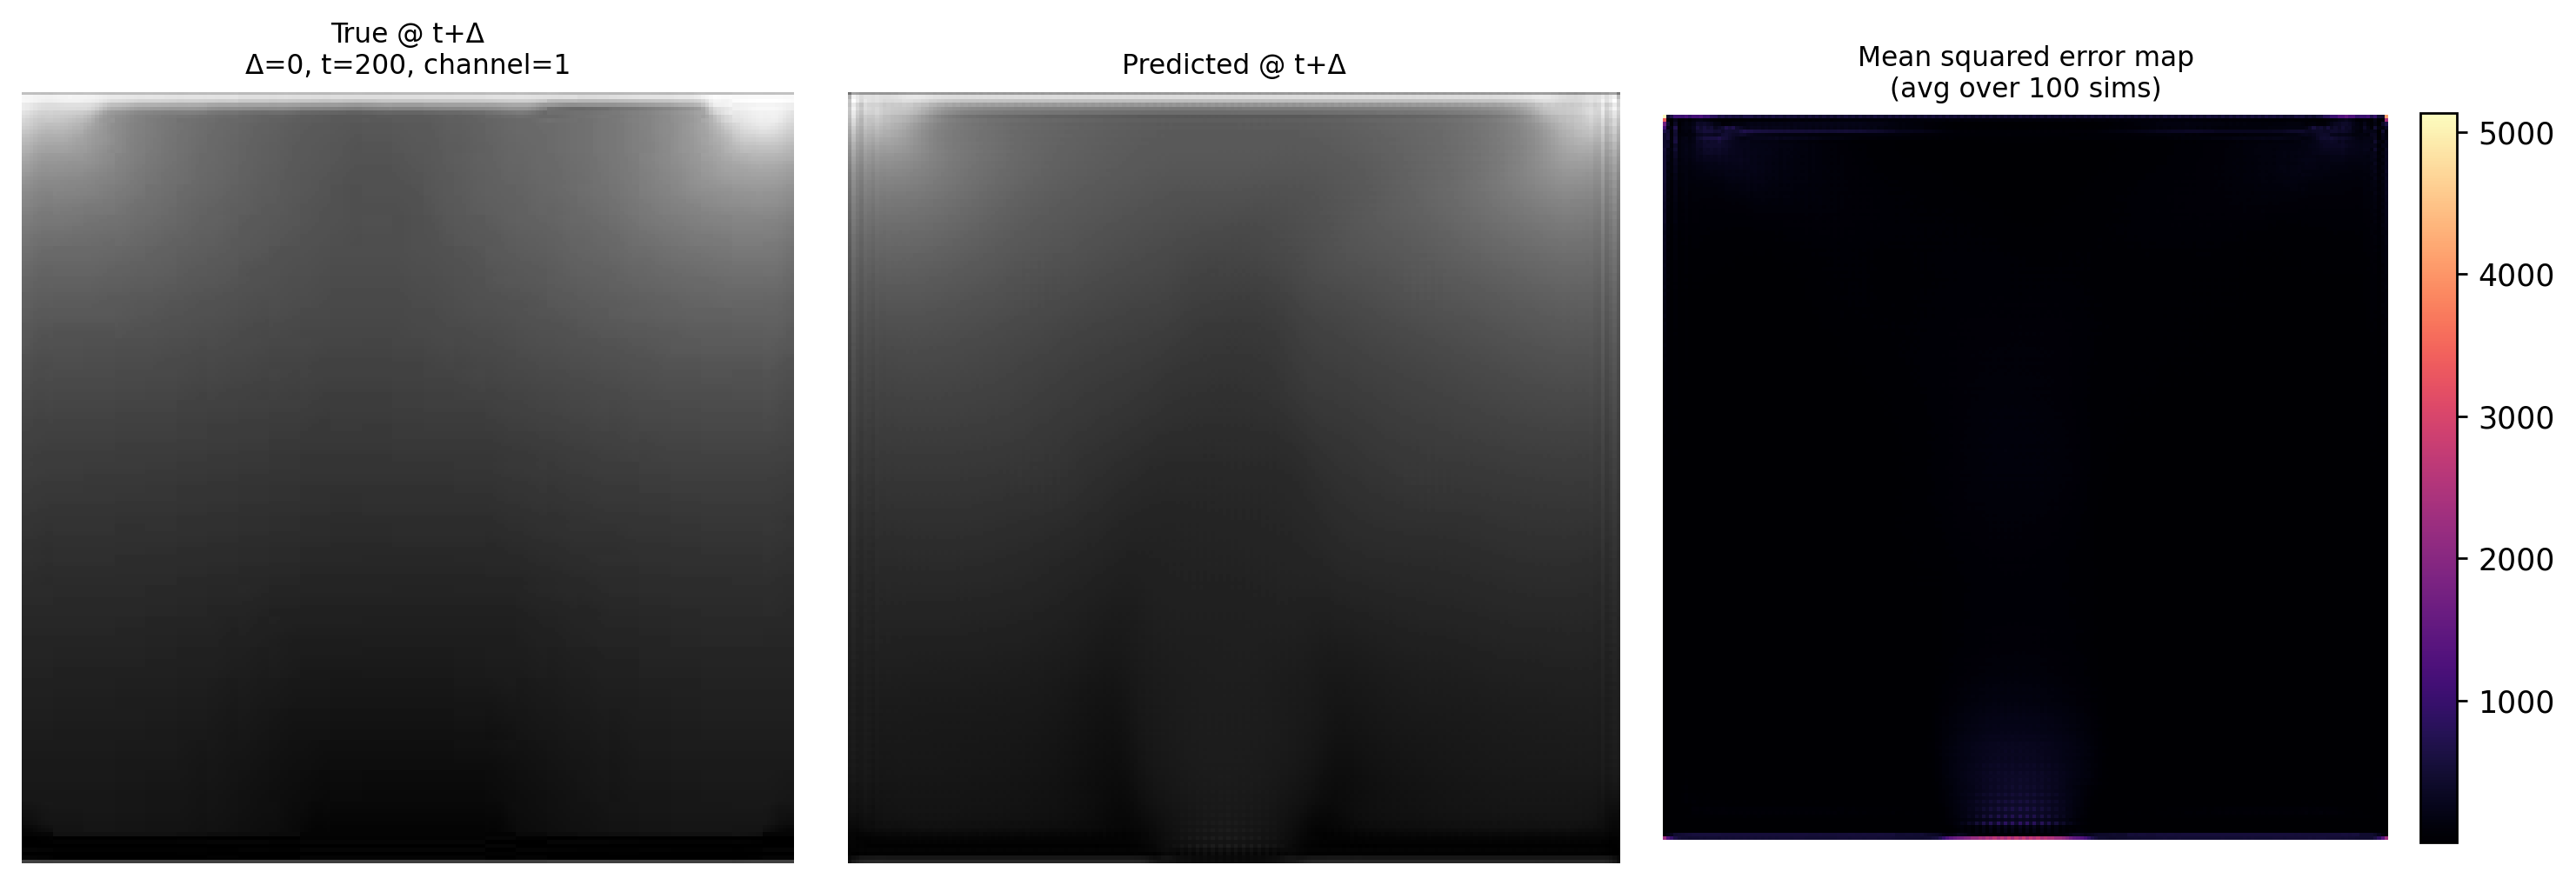

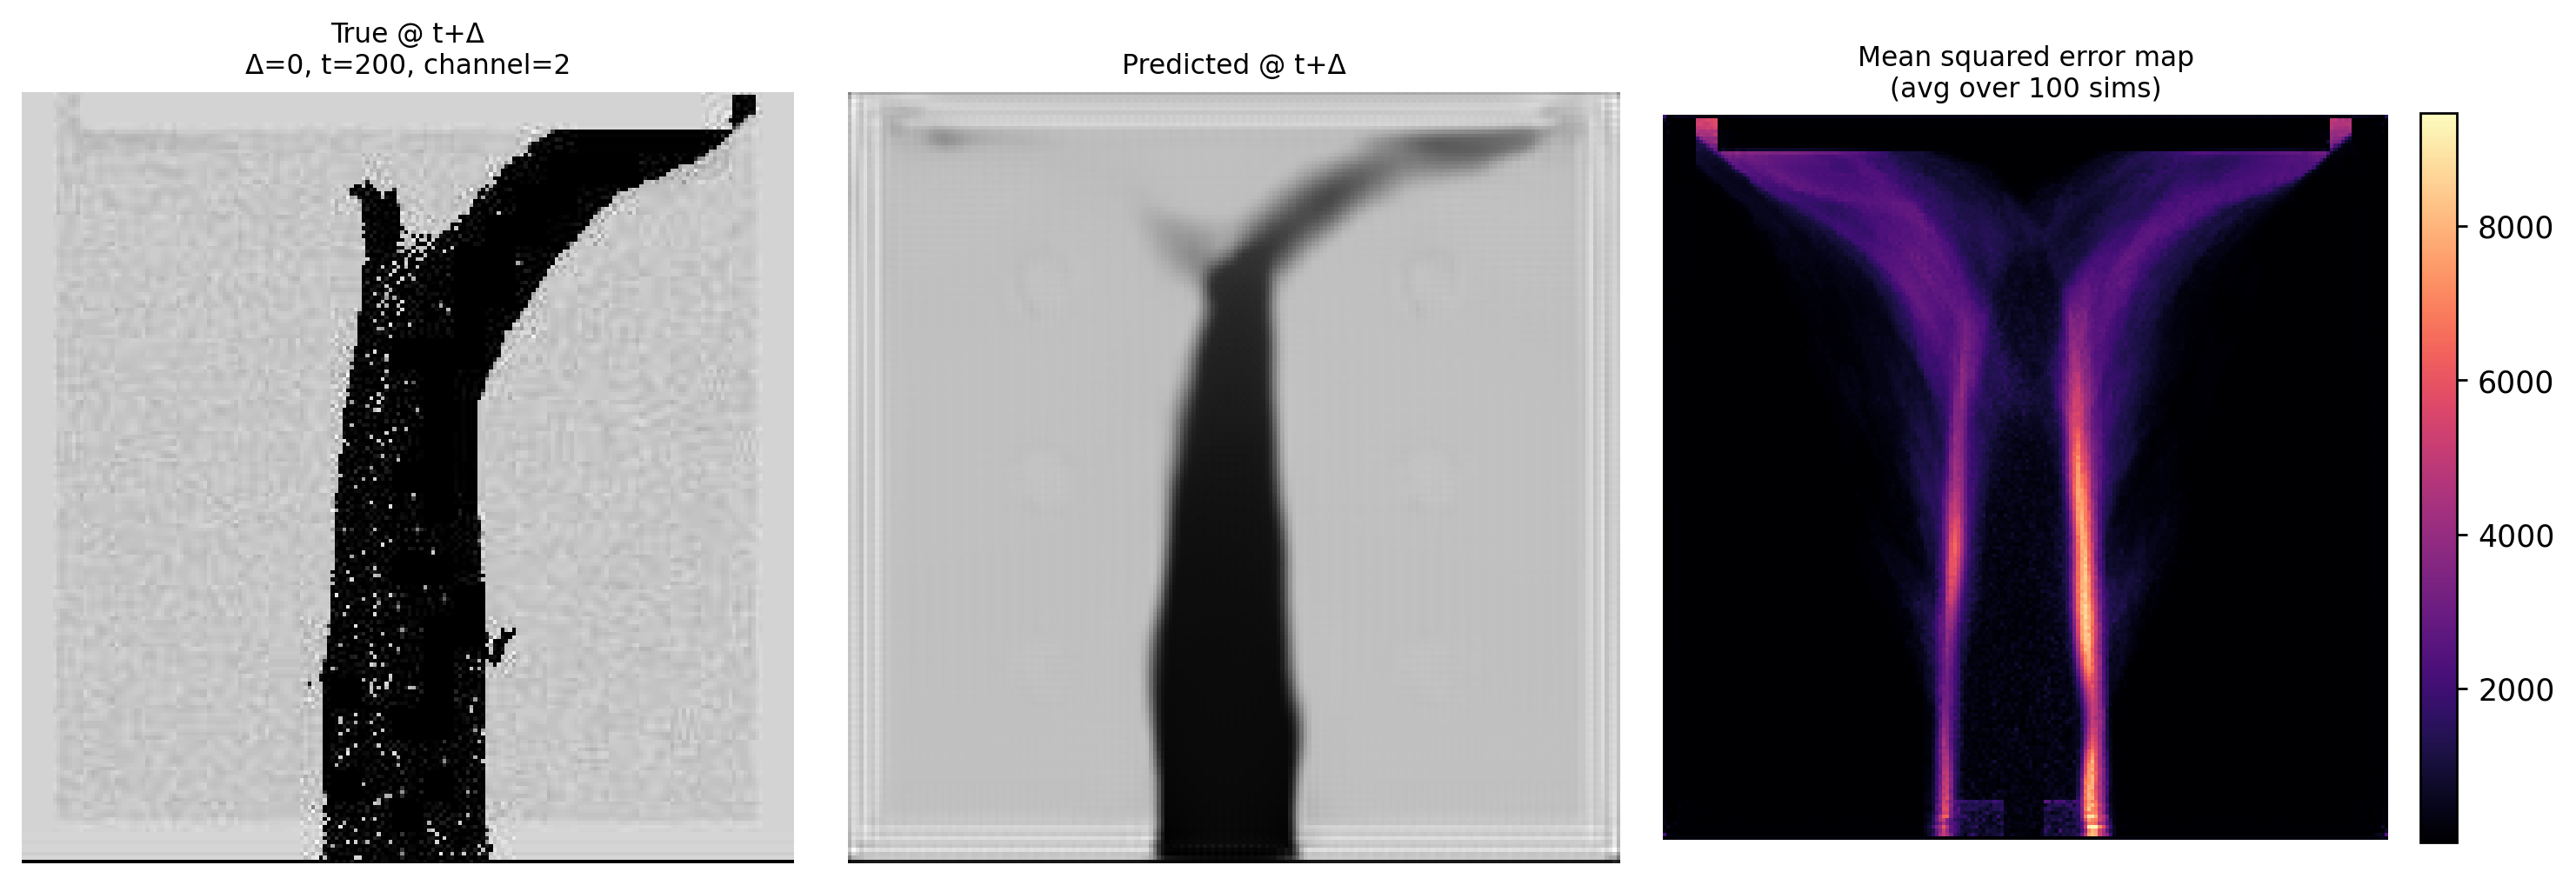

In [25]:
for ch in [0, 1, 2]:
    show_heatmap_mse_from_dataset(
        model=model,
        dataset_type=datasets.FixedDenseDatasetFull,
        dataset_arguments=dataset_arguments,
        val_sims=val_sims,
        future_delta=0,
        time_val=200,
        sims=None,
        channel=ch,
        device=device,
    )